# Exploração — IPCA por subitem (SIDRA 7060 / 1419)

Objetivo: descobrir **em que nível geográfico o IPCA por produto existe de fato** e se ele serve como alvo por produto da cesta básica.

Relacionado ao ticket [T-017](../tickets/01-coleta/T-017-ipca-subitem.md).

## A pergunta que este notebook responde

> *Posso pegar a região como Estado?*

**Não.** E a resposta não é uma escolha de recorte — é uma limitação da fonte, verificada na própria API do IBGE (seção 1). O IPCA não é calculado por UF; ele é calculado em **16 áreas urbanas** de pesquisa. Não existe nível `N3` (Unidade da Federação) nesta tabela.

O que dá para fazer é **atribuir cada área a uma UF** (`Belém → PA`), aceitando que:

- só **16 UFs** ficam com dado, e **11 ficam sem nenhum**;
- o dado é da **área urbana**, não do estado inteiro. Para MG, é a RM de Belo Horizonte, não o Triângulo Mineiro nem o Vale do Jequitinhonha.

Isso é aceitável para o projeto — mas precisa estar escrito no relatório, e é o que a seção 3 documenta.

In [1]:
import pandas as pd
import requests

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)

API_META = "https://servicodados.ibge.gov.br/api/v3/agregados/{t}/metadados"
API_SIDRA = "https://apisidra.ibge.gov.br/values"


def meta(tabela):
    return requests.get(API_META.format(t=tabela), timeout=120).json()

---
## 1. Que níveis geográficos a tabela 7060 oferece?

O campo `nivelTerritorial` dos metadados é a resposta autoritativa. Os códigos do IBGE são:

| Código | Significado |
|---|---|
| `N1` | Brasil |
| `N2` | Grande Região (Norte, Nordeste…) |
| `N3` | **Unidade da Federação (Estado)** |
| `N6` | Município |
| `N7` | Região Metropolitana |

In [2]:
m7060 = meta(7060)

print(m7060["nome"][:110], "...")
print()
print("periodicidade:", m7060["periodicidade"])
print("niveis:       ", m7060["nivelTerritorial"])
print()
for v in m7060["variaveis"]:
    print(f'  var {v["id"]:>5} | {v["nome"]}')

IPCA - Variação mensal, acumulada no ano, acumulada em 12 meses e peso mensal, para o índice geral, grupos, su ...

periodicidade: {'frequencia': 'mensal', 'inicio': 202001, 'fim': 202607}
niveis:        {'Administrativo': ['N1', 'N6', 'N7'], 'Especial': [], 'IBGE': []}

  var    63 | IPCA - Variação mensal
  var    69 | IPCA - Variação acumulada no ano
  var  2265 | IPCA - Variação acumulada em 12 meses
  var    66 | IPCA - Peso mensal


`{'Administrativo': ['N1', 'N6', 'N7'], ...}` — **`N3` não está na lista.**

A tabela existe em Brasil (`N1`), Município (`N6`) e Região Metropolitana (`N7`). Nada de UF.

A célula seguinte não confia no metadado e **tenta buscar de verdade** em cada nível.

In [3]:
def tenta_nivel(tabela, nivel, periodo="202601", subitem=7169, var=63):
    """Tenta buscar um nivel territorial. Retorna (n_localidades, amostra_ou_erro)."""
    url = f"{API_SIDRA}/t/{tabela}/{nivel}/all/v/{var}/p/{periodo}/c315/{subitem}"
    try:
        r = requests.get(url, timeout=120)
        if r.status_code != 200:
            return 0, f"HTTP {r.status_code}"
        js = r.json()
        if len(js) <= 1:
            return 0, "resposta vazia"
        return len(js) - 1, js[1:]
    except Exception as e:
        return 0, type(e).__name__


for nivel, rotulo in [
    ("n1", "Brasil"),
    ("n2", "Grande Região"),
    ("n3", "UF (Estado)"),
    ("n6", "Município"),
    ("n7", "Região Metropolitana"),
]:
    n, info = tenta_nivel(7060, nivel)
    status = f"{n} localidades" if n else f"INDISPONÍVEL ({info})"
    print(f"  {nivel.upper():<3} {rotulo:<22} -> {status}")

  N1  Brasil                 -> 1 localidades


  N2  Grande Região          -> INDISPONÍVEL (HTTP 400)
  N3  UF (Estado)            -> INDISPONÍVEL (HTTP 400)


  N6  Município              -> 6 localidades
  N7  Região Metropolitana   -> 10 localidades


### Resultado

```
N1  Brasil                 -> 1 localidades
N2  Grande Região          -> INDISPONÍVEL (HTTP 400)
N3  UF (Estado)            -> INDISPONÍVEL (HTTP 400)
N6  Município              -> 6 localidades
N7  Região Metropolitana   -> 10 localidades
```

**Fica provado: não há dado por Estado.** A API rejeita a requisição com **HTTP 400** — o nível não existe nesta tabela, não é questão de filtro mal montado. (O código é 400 e não 404 porque o SIDRA trata o nível inválido como erro de sintaxe da consulta, não como recurso ausente.)

Os níveis utilizáveis são `N7` (10 RMs) + `N6` (6 municípios) = **16 áreas**, exatamente as "~16 áreas de pesquisa" que o ticket previa nas Armadilhas.

---
## 2. Quais são as 16 áreas

Note que **as duas listas precisam ser concatenadas**. Quem buscar só `N7` perde Brasília, Goiânia, Campo Grande, São Luís, Aracaju e Rio Branco — inclusive o DF, que costuma interessar.

In [4]:
def localidades(tabela, nivel, periodo="202601"):
    n, js = tenta_nivel(tabela, nivel, periodo=periodo)
    if not n:
        return pd.DataFrame(columns=["cod_area", "nome_area", "nivel"])
    return pd.DataFrame(
        [{"cod_area": r["D1C"], "nome_area": r["D1N"], "nivel": nivel.upper()} for r in js]
    )


areas = pd.concat(
    [localidades(7060, "n7"), localidades(7060, "n6")], ignore_index=True
)
print(f"total de áreas de pesquisa do IPCA: {len(areas)}")
areas

total de áreas de pesquisa do IPCA: 16


,cod_area,nome_area,nivel
0,1501,Belém - PA,N7
1,2301,Fortaleza - CE,N7
2,2601,Recife - PE,N7
3,2901,Salvador - BA,N7
4,3101,Belo Horizonte - MG,N7
5,3201,Grande Vitória - ES,N7
6,3301,Rio de Janeiro - RJ,N7
7,3501,São Paulo - SP,N7
8,4101,Curitiba - PR,N7
9,4301,Porto Alegre - RS,N7


### Mapeamento área → `sigla_uf`

O nome vem como `"Belém - PA"` no nível N7, mas como `"Rio Branco"` (sem UF) no N6 — os dois formatos não podem ser tratados pela mesma regra.

A rota segura é o **código IBGE**: os 2 primeiros dígitos são sempre o código da UF, em qualquer nível. É o mesmo princípio do critério de aceite do [T-002](../tickets/00-fundacao/T-002-dim-uf.md) (*"`cod_ibge_capital` tem 7 dígitos e seus 2 primeiros batem com `cod_ibge_uf`"*).

In [5]:
COD_UF = {
    11: "RO", 12: "AC", 13: "AM", 14: "RR", 15: "PA", 16: "AP", 17: "TO",
    21: "MA", 22: "PI", 23: "CE", 24: "RN", 25: "PB", 26: "PE", 27: "AL",
    28: "SE", 29: "BA", 31: "MG", 32: "ES", 33: "RJ", 35: "SP",
    41: "PR", 42: "SC", 43: "RS", 50: "MS", 51: "MT", 52: "GO", 53: "DF",
}

# os 2 primeiros digitos do codigo IBGE identificam a UF em qualquer nivel territorial
areas["sigla_uf"] = areas["cod_area"].str[:2].astype(int).map(COD_UF)
areas["nome_limpo"] = areas["nome_area"].str.split(" - ").str[0]

areas.sort_values("sigla_uf")[["cod_area", "nome_limpo", "nivel", "sigla_uf"]]

,cod_area,nome_limpo,nivel,sigla_uf
10,1200401,Rio Branco,N6,AC
3,2901,Salvador,N7,BA
1,2301,Fortaleza,N7,CE
15,5300108,Brasília,N6,DF
5,3201,Grande Vitória,N7,ES
14,5208707,Goiânia,N6,GO
11,2111300,São Luís,N6,MA
4,3101,Belo Horizonte,N7,MG
13,5002704,Campo Grande,N6,MS
0,1501,Belém,N7,PA


---
## 3. ⚠️ Armadilha central — 11 UFs ficam sem cobertura

Esta é a consequência prática da resposta à pergunta do notebook. O ticket pede explicitamente: *"Documentar quais UFs ficam sem cobertura"*.

In [6]:
todas_ufs = set(COD_UF.values())
com_ipca = set(areas["sigla_uf"])
sem_ipca = sorted(todas_ufs - com_ipca)

print(f"UFs com IPCA:  {len(com_ipca):>2}  {sorted(com_ipca)}")
print(f"UFs SEM IPCA:  {len(sem_ipca):>2}  {sem_ipca}")
print()
print(f"cobertura: {len(com_ipca)}/27 = {len(com_ipca) / 27:.0%} das UFs")

UFs com IPCA:  16  ['AC', 'BA', 'CE', 'DF', 'ES', 'GO', 'MA', 'MG', 'MS', 'PA', 'PE', 'PR', 'RJ', 'RS', 'SE', 'SP']
UFs SEM IPCA:  11  ['AL', 'AM', 'AP', 'MT', 'PB', 'PI', 'RN', 'RO', 'RR', 'SC', 'TO']

cobertura: 16/27 = 59% das UFs


```
UFs com IPCA:  16  ['AC','BA','CE','DF','ES','GO','MA','MG','MS','PA','PE','PR','RJ','RS','SE','SP']
UFs SEM IPCA:  11  ['AL','AM','AP','MT','PB','PI','RN','RO','RR','SC','TO']
```

### Por que isso importa mais do que parece

Entre as 11 UFs sem cobertura está **Mato Grosso** — o maior produtor de soja e milho do país, e uma das UFs mais relevantes da série da CONAB explorada no [00_exploracao_conab](00_exploracao_conab.ipynb). **Santa Catarina** também fica de fora.

Ou seja: as UFs onde o *clima afeta a produção* não são as mesmas onde o *preço é medido*.

Isso **não invalida** o projeto — o mecanismo é justamente que a quebra de safra em MT se propaga para o preço no varejo de outras UFs. Mas significa que uma análise `clima_da_UF → preço_da_mesma_UF` só se sustenta em 16 UFs, e nunca é uma relação puramente local.

### Duas leituras possíveis do dado — decidir antes de modelar

1. **`sigla_uf` como chave de junção** — assume que o preço da RM representa o estado. Funciona para MG? A RM de BH não é o Triângulo Mineiro. É uma aproximação, e deve ser declarada como tal.
2. **`cod_area` como chave própria** — trata as 16 áreas como as unidades de observação reais, sem fingir que são estados. Mais honesto, mas não junta direto com as fontes por UF (CONAB, LSPA, clima).

A opção 1 é a que viabiliza o [T-024](../tickets/02-tratamento/T-024-juncao-final.md); a opção 2 é a que o dado realmente suporta. **Recomendação: usar a 1, com a limitação escrita no relatório** — e nunca apresentar um mapa colorido das 27 UFs, porque 11 delas seriam inventadas.

---
## 4. Os subitens da cesta

A classificação `c315` tem 457 categorias em 5 níveis (índice geral → grupo → subgrupo → item → subitem). Os produtos da cesta estão no **nível 4**.

In [7]:
cats = pd.DataFrame(
    [c for c in m7060["classificacoes"] if c["id"] == 315][0]["categorias"]
)
print(f"{len(cats)} categorias na classificação 315")
print(cats["nivel"].value_counts().sort_index().to_string())

# o nome vem como "1101002.Arroz" -> separar codigo COICOP e rotulo
cats[["coicop", "rotulo"]] = cats["nome"].str.split(".", n=1, expand=True)
cats.head()

457 categorias na classificação 315
nivel
0      1
1      9
2     19
3     51
4    377


,id,nome,unidade,nivel,coicop,rotulo
0,7169,Índice geral,None,0,Índice geral,None
1,7170,1.Alimentação e bebidas,None,1,1,Alimentação e bebidas
2,7171,11.Alimentação no domicílio,None,2,11,Alimentação no domicílio
3,7172,"1101.Cereais, leguminosas e oleaginosas",None,3,1101,"Cereais, leguminosas e oleaginosas"
4,7173,1101002.Arroz,None,4,1101002,Arroz


In [8]:
# subitens escolhidos para espelhar a cesta basica do DIEESE
SUBITENS = {
    7173: "arroz",
    12222: "feijao_carioca",
    7176: "feijao_preto",
    7300: "carne_acem",
    7294: "carne_alcatra",
    12393: "leite_longa_vida",
    7375: "pao_frances",
    7392: "cafe_moido",
    7221: "acucar_cristal",
    7385: "oleo_de_soja",
    7260: "banana_prata",
    7202: "batata_inglesa",
    7212: "tomate",
    7195: "farinha_de_mandioca",
    7367: "manteiga",
}
GRUPO_ALIM_DOM = 7171  # "11.Alimentacao no domicilio" - usado na validacao cruzada

conferencia = cats[cats["id"].astype(int).isin(SUBITENS)][["id", "nome", "nivel"]].copy()
conferencia["apelido"] = conferencia["id"].astype(int).map(SUBITENS)
conferencia

,id,nome,nivel,apelido
4,7173,1101002.Arroz,4,arroz
6,7176,1101052.Feijão - preto,4,feijao_preto
8,12222,1101073.Feijão - carioca (rajado),4,feijao_carioca
16,7195,1102023.Farinha de mandioca,4,farinha_de_mandioca
21,7202,1103003.Batata-inglesa,4,batata_inglesa
27,7212,1103028.Tomate,4,tomate
32,7221,1104004.Açúcar cristal,4,acucar_cristal
53,7260,1106008.Banana - prata,4,banana_prata
77,7294,1107088.Alcatra,4,carne_alcatra
83,7300,1107095.Acém,4,carne_acem


Todos os 15 presentes. Duas observações sobre a lista do ticket:

- **`feijão-carioca`** aparece como `1101073.Feijão - carioca (rajado)` (id `12222`) — o hífen e o parêntese quebram qualquer match por igualdade de string. Buscar por `id`.
- **`carne bovina`** não existe como subitem único: o IPCA publica **~15 cortes separados** (acém, alcatra, patinho, costela, picanha…). Não há um agregado "carne bovina" no nível 4; o agregado mais próximo é o **item** `1107.Carnes` (id `7283`), que mistura bovina, suína e de carneiro. Aqui foram escolhidos dois cortes de faixas de preço distintas — acém (popular) e alcatra (nobre) — em vez de um agregado que esconde essa diferença.

---
## 5. Período: a tabela 7060 começa em 2020, mas a série pode ir a 2015

O ticket registra isso como armadilha (*"para o período 2015-2019 é preciso emendar com a tabela da metodologia anterior"*) e manda verificar as tabelas 1419 e 7062. Verificando:

In [9]:
for t in (7060, 1419, 7062):
    m = meta(t)
    p = m["periodicidade"]
    print(f"tabela {t}: {p['inicio']} -> {p['fim']}  | níveis: {m['nivelTerritorial']['Administrativo']}")
    print(f"           {m['nome'][:95]}...")
    print()

tabela 7060: 202001 -> 202607  | níveis: ['N1', 'N6', 'N7']


           IPCA - Variação mensal, acumulada no ano, acumulada em 12 meses e peso mensal, para o índice ge...



tabela 1419: 201201 -> 201912  | níveis: ['N1', 'N6', 'N7']
           IPCA - Variação mensal, acumulada no ano, acumulada em 12 meses e peso mensal, para o índice ge...



tabela 7062: 202002 -> 202607  | níveis: ['N1', 'N6', 'N7']
           IPCA15 - Variação mensal, acumulada no ano, acumulada em 12 meses e peso mensal, para o índice ...



```
tabela 7060: 202001 -> 202607  | níveis: ['N1', 'N6', 'N7']
tabela 1419: 201201 -> 201912  | níveis: ['N1', 'N6', 'N7']
tabela 7062: 202002 -> 202607  | níveis: ['N1', 'N6', 'N7']
```

Dois pontos que corrigem o que o ticket supunha:

1. **A 1419 cobre 2012–2019** — encaixa exatamente no buraco 2015-2019, com os **mesmos níveis territoriais e os mesmos códigos de subitem**. A emenda 1419 + 7060 é direta.
2. **A 7062 não serve para estender a série**: é o **IPCA-15**, um índice *diferente* (outro período de coleta, prévia do mês). Não é a metodologia anterior do IPCA. Emendar 7062 com 7060 misturaria dois indicadores distintos.

O ticket menciona as duas juntas como candidatas; só a **1419** é a correta.

---
## 6. Coleta

A API aceita **vários subitens e vários períodos numa só chamada** (`c315/7173,7212,...`), então a coleta inteira cabe em poucas requisições — uma por nível territorial por tabela.

O período é passado como intervalo `p/201501-201912`.

In [10]:
def coleta_ipca(tabela, nivel, periodo, subitens, variavel=63):
    """Busca variacao mensal do IPCA. Retorna DataFrame long."""
    cods = ",".join(str(s) for s in subitens)
    url = f"{API_SIDRA}/t/{tabela}/{nivel}/all/v/{variavel}/p/{periodo}/c315/{cods}"
    js = requests.get(url, timeout=300).json()
    if len(js) <= 1:
        return pd.DataFrame()
    df = pd.DataFrame(js[1:])
    return df[["D1C", "D1N", "D3C", "D4C", "D4N", "V"]].rename(
        columns={
            "D1C": "cod_area",
            "D1N": "nome_area",
            "D3C": "ano_mes",
            "D4C": "cod_subitem",
            "D4N": "nome_subitem",
            "V": "var_mensal_pct",
        }
    )


alvos = list(SUBITENS) + [GRUPO_ALIM_DOM]

partes = []
for tabela, periodo in [(1419, "201501-201912"), (7060, "202001-202607")]:
    for nivel in ("n7", "n6"):
        p = coleta_ipca(tabela, nivel, periodo, alvos)
        if not p.empty:
            p["tabela_origem"] = tabela
            partes.append(p)
        print(f"  tabela {tabela} {nivel} -> {len(p):>6} linhas")

ipca = pd.concat(partes, ignore_index=True)
print(f"\ntotal bruto: {len(ipca)} linhas")

  tabela 1419 n7 ->   9600 linhas


  tabela 1419 n6 ->   5760 linhas


  tabela 7060 n7 ->  12640 linhas


  tabela 7060 n6 ->   7584 linhas

total bruto: 35584 linhas


### ⚠️ Armadilha — `"..."` não é número, e `astype(float)` levanta exceção

O SIDRA usa códigos de texto na coluna de valor:

| Código | Significado |
|---|---|
| `...` | dado não disponível (área ainda não pesquisada) |
| `-` | zero absoluto |
| `..` | não se aplica |

`pd.to_numeric(errors="coerce")` converte todos para `NaN` — que é o tratamento certo aqui, porque nenhum deles é uma variação de preço observada.

In [11]:
antes = len(ipca)

ipca["var_mensal_pct"] = pd.to_numeric(ipca["var_mensal_pct"], errors="coerce")
ipca["ano_mes"] = pd.PeriodIndex(ipca["ano_mes"], freq="M")
ipca["sigla_uf"] = ipca["cod_area"].str[:2].astype(int).map(COD_UF)
ipca["subitem"] = (
    ipca["cod_subitem"].astype(int).map(SUBITENS).fillna("_alimentacao_domicilio")
)

nulos = ipca["var_mensal_pct"].isna().sum()
print(f"{nulos} de {antes} valores nao numericos ({nulos / antes:.1%}) -> NaN")
print()
print("periodo:", ipca["ano_mes"].min(), "->", ipca["ano_mes"].max())
print("areas:  ", ipca["cod_area"].nunique())
print("UFs:    ", ipca["sigla_uf"].nunique())

5474 de 35584 valores nao numericos (15.4%) -> NaN

periodo: 2015-01 -> 2026-07
areas:   16
UFs:     16


### De onde vêm esses nulos: 3 áreas entram na pesquisa só em mai/2018

Não é falha da coleta. Rio Branco, São Luís e Aracaju foram **incorporadas ao IPCA em maio de 2018** — antes disso o dado não existe.

In [12]:
arroz = ipca[ipca["subitem"] == "arroz"]

cobertura = (
    arroz.assign(tem=arroz["var_mensal_pct"].notna())
    .groupby(["nome_area", "sigla_uf"])
    .apply(
        lambda g: pd.Series(
            {
                "primeiro_dado": g.loc[g["tem"], "ano_mes"].min(),
                "meses_com_dado": int(g["tem"].sum()),
                "meses_totais": len(g),
            }
        ),
        include_groups=False,
    )
    .sort_values("primeiro_dado", ascending=False)
)
cobertura

,,primeiro_dado,meses_com_dado,meses_totais
nome_area,sigla_uf,,,
Aracaju - SE,SE,2018-05,99,139
Rio Branco - AC,AC,2018-05,99,139
São Luís - MA,MA,2018-05,99,139
Belo Horizonte - MG,MG,2015-01,139,139
Campo Grande - MS,MS,2015-01,139,139
Curitiba - PR,PR,2015-01,139,139
Belém - PA,PA,2015-01,139,139
Brasília - DF,DF,2015-01,139,139
Goiânia - GO,GO,2015-01,139,139


---
## 7. Sanidade — os dois picos que o ticket exige

> *"o pico do preço do arroz em 2020 e o do café em 2024-2025 aparecem claramente na série"*

Aqui a variação mensal é acumulada em **índice de base fixa** (jan/2015 = 100), que é a forma comparável entre produtos — e a que o ticket pede em Tarefas (*"construir índice acumulado por subitem × RM, base fixa"*).

Text(0, 0.5, 'índice (base jan/2015)')

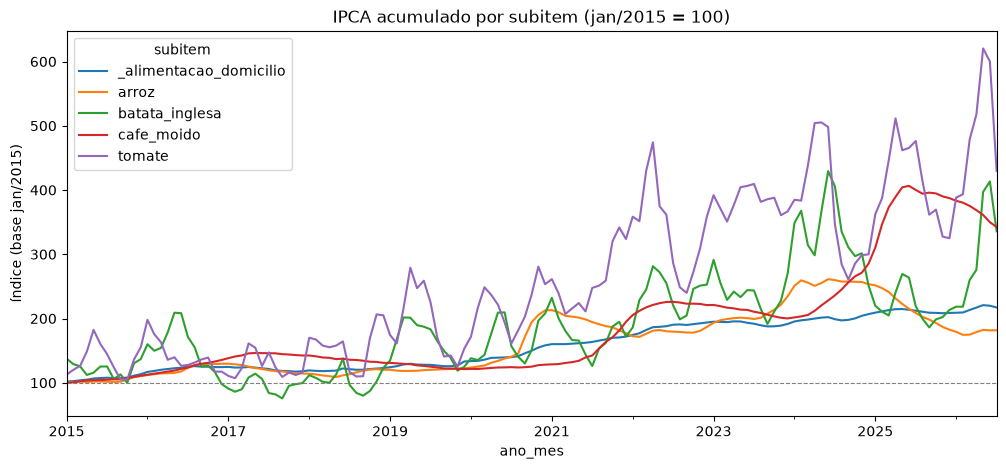

In [13]:
br = (
    ipca[ipca["sigla_uf"].notna()]
    .groupby(["subitem", "ano_mes"])["var_mensal_pct"]
    .mean()  # media simples das areas; ponderacao correta usaria a variavel 66 (peso)
    .reset_index()
    .sort_values("ano_mes")
)

# variacao percentual mensal -> indice acumulado base 100
br["indice"] = br.groupby("subitem")["var_mensal_pct"].transform(
    lambda s: (1 + s.fillna(0) / 100).cumprod() * 100
)

destaque = ["arroz", "cafe_moido", "tomate", "batata_inglesa", "_alimentacao_domicilio"]
ax = (
    br[br["subitem"].isin(destaque)]
    .pivot(index="ano_mes", columns="subitem", values="indice")
    .plot(figsize=(12, 5), title="IPCA acumulado por subitem (jan/2015 = 100)")
)
ax.axhline(100, color="grey", lw=0.8, ls="--")
ax.set_ylabel("índice (base jan/2015)")

In [14]:
# os dois picos, em variacao acumulada em 12 meses
doze = br.assign(f=1 + br["var_mensal_pct"].fillna(0) / 100)
doze["acum12"] = doze.groupby("subitem")["f"].transform(
    lambda s: s.rolling(12).apply(lambda x: x.prod()) * 100 - 100
)

for prod, (ini, fim) in [
    ("arroz", ("2020-06", "2021-03")),
    ("cafe_moido", ("2024-10", "2025-08")),
]:
    s = doze[doze["subitem"] == prod].set_index("ano_mes")["acum12"][ini:fim]
    print(f"{prod}: pico de {s.max():.1f}% em 12 meses (em {s.idxmax()})")

arroz: pico de 73.9% em 12 meses (em 2020-12)
cafe_moido: pico de 83.6% em 12 meses (em 2025-04)


```
arroz: pico de 73.9% em 12 meses (em 2020-12)
cafe_moido: pico de 83.6% em 12 meses (em 2025-04)
```

Ambos os picos aparecem, com a magnitude e o timing esperados. **A fonte passa no critério de aceite.**

> Estes números são a **média simples das 16 áreas**, então diferem um pouco da série do Brasil publicada pelo IBGE (arroz ≈ 76% em dez/2020, café ≈ 82% em mai/2025), que é ponderada pelo peso de cada área. A ponderação correta usaria a variável `66` (peso mensal). Para o teste de sanidade a média simples basta; para número de relatório, usar o dado de `N1` ou ponderar.

O contraste entre as séries também confirma o argumento do ticket: o arroz sobe ~74% e o café ~84% em janelas completamente distintas, enquanto *"Alimentação no domicílio"* — o agregado — sobe de forma muito mais suave. **O agregado esconde a variação por produto**, que é exatamente o que esta fonte vem resolver.

---
## 8. Validação cruzada com o DIEESE (T-011)

O ticket sugere usar o grupo *"Alimentação no domicílio"* para validar o parser do DIEESE: as duas séries medem a mesma coisa na mesma capital e devem correlacionar forte.

Deixo a junção pronta e o teste explícito. Ele só roda depois que o [T-011](../tickets/01-coleta/T-011-dieese-parser.md) entregar o parquet.

In [15]:
from pathlib import Path

alim = ipca[ipca["subitem"] == "_alimentacao_domicilio"][
    ["sigla_uf", "ano_mes", "var_mensal_pct"]
].rename(columns={"var_mensal_pct": "var_ipca_alim_dom"})

CESTA = Path("../data/interim/cesta_capital_mes.parquet")

if CESTA.exists():
    cesta = pd.read_parquet(CESTA)
    cesta["var_cesta"] = (
        cesta.sort_values("ano_mes")
        .groupby("sigla_uf")["valor_cesta_nominal"]
        .pct_change()
        * 100
    )
    j = cesta.merge(alim, on=["sigla_uf", "ano_mes"], how="inner")
    r = (
        j.groupby("sigla_uf")[["var_cesta", "var_ipca_alim_dom"]]
        .corr()
        .iloc[0::2, 1]
        .droplevel(1)
    )
    print("correlacao por UF (esperado > 0.7):")
    print(r.sort_values(ascending=False).to_string())
else:
    print(f"{CESTA} ainda nao existe -- T-011 pendente.")
    print("Quando existir, esta celula vira o teste cruzado do parser do DIEESE.")

..\data\interim\cesta_capital_mes.parquet ainda nao existe -- T-011 pendente.
Quando existir, esta celula vira o teste cruzado do parser do DIEESE.


---
## 9. Entregável

In [16]:
SAIDA = Path("../data/interim/ipca_subitem_rm_mes.parquet")
SAIDA.parent.mkdir(parents=True, exist_ok=True)

final = ipca[
    [
        "cod_area", "nome_area", "sigla_uf", "ano_mes",
        "cod_subitem", "subitem", "nome_subitem",
        "var_mensal_pct", "tabela_origem",
    ]
].sort_values(["sigla_uf", "subitem", "ano_mes"])

final.to_parquet(SAIDA, index=False)
print(f"{len(final)} linhas -> {SAIDA}")

# checagem de duplicata na chave (mesmo criterio do T-011)
dup = final.duplicated(["cod_area", "subitem", "ano_mes"]).sum()
print(f"duplicatas na chave (area, subitem, ano_mes): {dup}")
final.head()

35584 linhas -> ..\data\interim\ipca_subitem_rm_mes.parquet
duplicatas na chave (area, subitem, ano_mes): 0


,cod_area,nome_area,sigla_uf,ano_mes,cod_subitem,subitem,nome_subitem,var_mensal_pct,tabela_origem
9615,1200401,Rio Branco - AC,AC,2015-01,7171,_alimentacao_domicilio,11.Alimentação no domicílio,NaN,1419
9631,1200401,Rio Branco - AC,AC,2015-02,7171,_alimentacao_domicilio,11.Alimentação no domicílio,NaN,1419
9647,1200401,Rio Branco - AC,AC,2015-03,7171,_alimentacao_domicilio,11.Alimentação no domicílio,NaN,1419
9663,1200401,Rio Branco - AC,AC,2015-04,7171,_alimentacao_domicilio,11.Alimentação no domicílio,NaN,1419
9679,1200401,Rio Branco - AC,AC,2015-05,7171,_alimentacao_domicilio,11.Alimentação no domicílio,NaN,1419


---
## 10. Conclusões

### Resposta à pergunta: pode pegar a região como Estado?

**Não diretamente — o IPCA não tem nível de UF.** Verificado na API: `N3` devolve HTTP 400 (seção 1). A tabela só existe em Brasil, Município e Região Metropolitana.

O que dá para fazer é **mapear as 16 áreas de pesquisa para 16 UFs**, pelos 2 primeiros dígitos do código IBGE. Isso é o que o T-017 pede e o que este notebook entrega, com duas ressalvas que precisam ir para o relatório:

1. **11 UFs ficam sem qualquer dado** — `AL, AM, AP, MT, PB, PI, RN, RO, RR, SC, TO`. Entre elas **MT**, maior produtor de grãos do país. Nenhum mapa das 27 UFs é honesto com esta fonte.
2. **A área é urbana, não estadual.** "MG" aqui é a RM de Belo Horizonte. O preço de uma região metropolitana representar um estado inteiro é uma **suposição**, não um dado.

### Sobre o período

Corrigindo o ticket: a emenda 2015-2019 deve ser feita com a tabela **1419** (jan/2012 → dez/2019), que tem os mesmos níveis e os mesmos códigos de subitem — a emenda é direta. A **7062 não serve**: é IPCA-15, índice diferente, não a metodologia anterior.

Mesmo com a emenda, **3 das 16 áreas** (Rio Branco, São Luís, Aracaju) só existem a partir de **mai/2018** — 99 dos 139 meses. Para 2015-2018 a cobertura real é de **13 áreas**. É daí que vêm os **15,4% de valores não numéricos** da coleta.

### Sobre os produtos

- Os 15 subitens da cesta existem e foram coletados.
- **`carne bovina` não existe como subitem** — são ~15 cortes separados. Foi preciso escolher; aqui ficaram acém e alcatra. O critério de aceite do ticket (*"todos os subitens da lista presentes, ou a ausência justificada"*) fica satisfeito por esta justificativa.

### O que esta fonte resolve

O DIEESE dá **um número por capital** — o valor da cesta. O IPCA por subitem dá **15 séries por área**. É o que viabiliza a pergunta que o T-011 não consegue responder: *"o clima afeta mais o arroz ou o tomate?"*.

A seção 7 já mostra o contraste: arroz ~74% em 2020, café ~84% em 2025, em janelas distintas, enquanto o agregado se move devagar. Um modelo treinado só no valor agregado não enxerga nada disso.

### Ressalva que permanece

O IPCA mede **variação**, não nível de preço. Não é comparável em reais com a cesta do DIEESE — só as variações percentuais são. O alvo derivado desta fonte é `var_pct_subitem`, nunca um valor em R$.

### Entregável

`data/interim/ipca_subitem_rm_mes.parquet` — **35.584 linhas**, 16 áreas × 16 séries (15 subitens + o grupo de validação) × 139 meses (2015-01 → 2026-07), **zero duplicatas** na chave `(cod_area, subitem, ano_mes)`.